How much revenue are we expected to generate next month?

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

from statsmodels.tsa.arima.model import ARIMA

In [6]:
df = pd.read_csv(r"C:\Users\amit6\OneDrive\Desktop\Intelligent-Retail-Customer-Analytics\Data\Processed_data\retail_feature_engineered.csv")
df.head()

C:\Users\amit6\AppData\Local\Temp\ipykernel_17556\3849823998.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"C:\Users\amit6\OneDrive\Desktop\Intelligent-Retail-Customer-Analytics\Data\Processed_data\retail_feature_engineered.csv")


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalAmount,Year,...,Hour,IsWeekend,InvoiceTotal,BasketSize,PurchaseFrequency,AverageOrderValue,CustomerRevenue,ProductPurchaseCount,ProductRevenue,CustomerType
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,...,7,False,505.3,8,8.0,350.900238,2433.28,522,21201.13,Regular
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,...,7,False,505.3,8,8.0,350.900238,2433.28,266,13787.93,Regular
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,...,7,False,505.3,8,8.0,350.900238,2433.28,350,18048.72,Regular
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009,...,7,False,505.3,8,8.0,350.900238,2433.28,560,18650.87,Regular
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009,...,7,False,505.3,8,8.0,350.900238,2433.28,2478,49300.57,Regular


In [7]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [28]:
monthly_sales = (
    df.groupby(pd.Grouper(key="InvoiceDate", freq="ME"))["TotalAmount"]
      .sum()
)

In [30]:
monthly_sales.head()

InvoiceDate
2009-12-31    822483.950
2010-01-31    651155.112
2010-02-28    551504.726
2010-03-31    830915.261
2010-04-30    678875.252
Freq: ME, Name: TotalAmount, dtype: float64

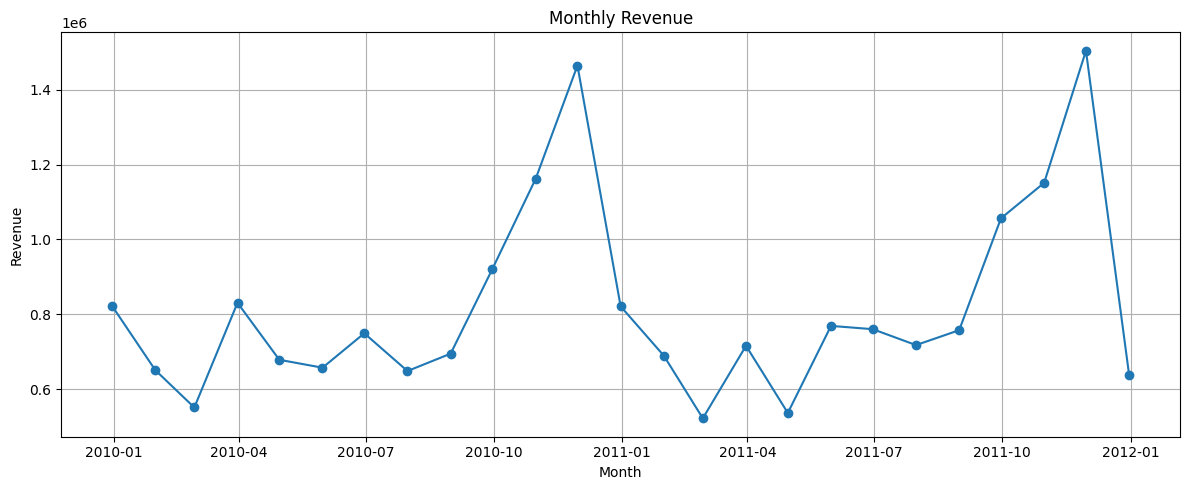

In [31]:
plt.figure(figsize=(12,5))

plt.plot(monthly_sales, marker="o")

plt.title("Monthly Revenue")

plt.xlabel("Month")

plt.ylabel("Revenue")

plt.grid(True)
plt.tight_layout()
plt.show()

In [32]:
train = monthly_sales[:-3]

test = monthly_sales[-3:]

In [33]:

model = ARIMA(train, order=(2,1,2))

model_fit = model.fit()

c:\Users\amit6\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


In [34]:
forecast = model_fit.forecast(steps=3)

In [35]:
mae = mean_absolute_error(test, forecast)

rmse = np.sqrt(mean_squared_error(test, forecast))

print("MAE :", mae)

print("RMSE:", rmse)

MAE : 339127.6025516338
RMSE: 378179.42900915985


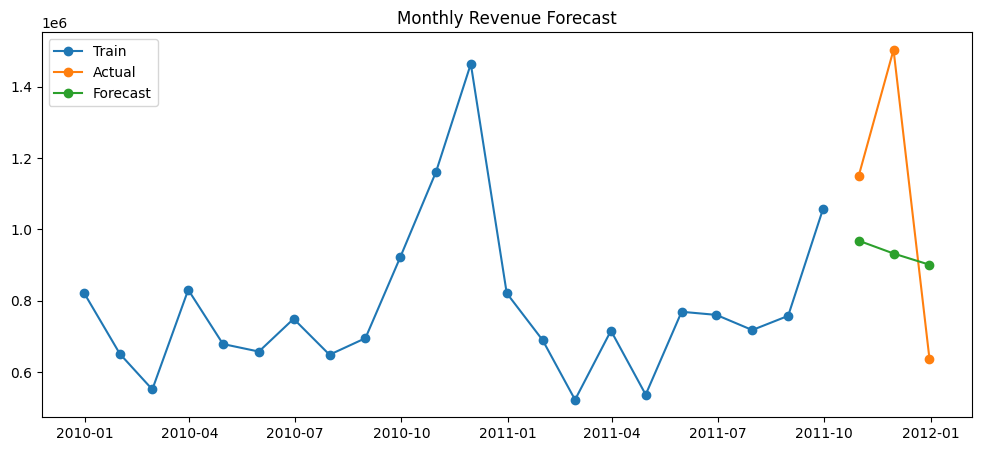

In [36]:
plt.figure(figsize=(12,5))

plt.plot(train.index, train.values, label="Train", marker="o")

plt.plot(test.index, test.values, label="Actual", marker="o")

plt.plot(test.index, forecast, label="Forecast", marker="o")

plt.legend()

plt.title("Monthly Revenue Forecast")

plt.show()

In [25]:
future = model_fit.forecast(

    steps=30

)

In [26]:
print(future)

2011-11-10    71084.574558
2011-11-11    42050.631520
2011-11-12    39262.545420
2011-11-13    65086.861664
2011-11-14    62623.007562
2011-11-15    58048.279850
2011-11-16    63624.423310
2011-11-17    56759.650533
2011-11-18    48002.980734
2011-11-19    56340.182758
2011-11-20    60888.275330
2011-11-21    57932.215450
2011-11-22    58986.296240
2011-11-23    59037.157029
2011-11-24    54340.766750
2011-11-25    55033.470163
2011-11-26    58418.960524
2011-11-27    58143.973405
2011-11-28    57626.614748
2011-11-29    58314.051948
2011-11-30    56878.834559
2011-12-01    55954.801365
2011-12-02    57225.629846
2011-12-03    57839.368820
2011-12-04    57445.436794
2011-12-05    57655.137927
2011-12-06    57456.135751
2011-12-07    56811.602219
2011-12-08    56997.489315
2011-12-09    57488.463311
Freq: D, Name: predicted_mean, dtype: float64
